In [1]:
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('AI_Image_Detection_Data.csv')

In [3]:
df.head(10)

,Image_Id,Image_Type,Is_Compressed,Compression_Quality,Detector_Name,Detector_Prediction,Is_Prediction_Correct
0,1.jpeg,Real,No,30,FaceOnLive,Real,Yes
1,1.jpeg,Real,No,30,BrandWell,Real,Yes
2,1.jpeg,Real,No,30,DFDetect,Real,Yes
3,C1-1.jpeg,Real,Yes,20,FaceOnLive,Real,Yes
4,C1-1.jpeg,Real,Yes,20,BrandWell,Real,Yes
5,C1-1.jpeg,Real,Yes,20,DFDetect,Real,Yes
6,C2-1.jpeg,Real,Yes,10,FaceOnLive,Uncertain,No
7,C2-1.jpeg,Real,Yes,10,BrandWell,Real,Yes
8,C2-1.jpeg,Real,Yes,10,DFDetect,Real,Yes
9,C3-1.jpeg,Real,Yes,1,FaceOnLive,Uncertain,No


In [4]:
df.tail(10)

,Image_Id,Image_Type,Is_Compressed,Compression_Quality,Detector_Name,Detector_Prediction,Is_Prediction_Correct
2390,200.jpeg,Fake,No,30,DFDetect,Real,No
2391,C1-200.jpeg,Fake,Yes,20,FaceOnLive,Fake,Yes
2392,C1-200.jpeg,Fake,Yes,20,BrandWell,Fake,Yes
2393,C1-200.jpeg,Fake,Yes,20,DFDetect,Fake,Yes
2394,C2-200.jpeg,Fake,Yes,10,FaceOnLive,Uncertain,No
2395,C2-200.jpeg,Fake,Yes,10,BrandWell,Fake,Yes
2396,C2-200.jpeg,Fake,Yes,10,DFDetect,Fake,Yes
2397,C3-200.jpeg,Fake,Yes,1,FaceOnLive,Real,No
2398,C3-200.jpeg,Fake,Yes,1,BrandWell,Real,No
2399,C3-200.jpeg,Fake,Yes,1,DFDetect,Fake,Yes


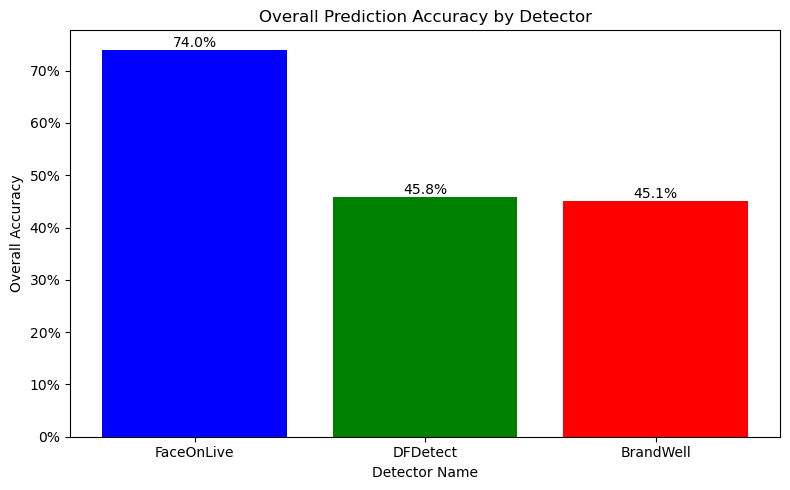

In [5]:
# Calculate the overall accuracy for each detector
accuracy_by_detector = df.groupby('Detector_Name')['Is_Prediction_Correct'].apply(
    lambda x: (x == 'Yes').sum() / len(x)
).reset_index(name='Overall_Accuracy')

# Sort by accuracy (required for correct bar order)
accuracy_by_detector = accuracy_by_detector.sort_values(by='Overall_Accuracy', ascending=False)

# Create the matplotlib bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(
    accuracy_by_detector['Detector_Name'],
    accuracy_by_detector['Overall_Accuracy'],
    color=['blue', 'green', 'red'] # Simple color scheme
)

# Add title and labels
plt.title('Overall Prediction Accuracy by Detector')
plt.xlabel('Detector Name')
plt.ylabel('Overall Accuracy')

# Add the value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0,
        yval,
        f'{yval:.1%}', # Format as percentage with one decimal place
        ha='center',
        va='bottom'
    )

# Set y-axis to display in percentage format (0% to 100%)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))

# Ensure layout is tight to prevent labels from being cut off
plt.tight_layout()

plt.show()

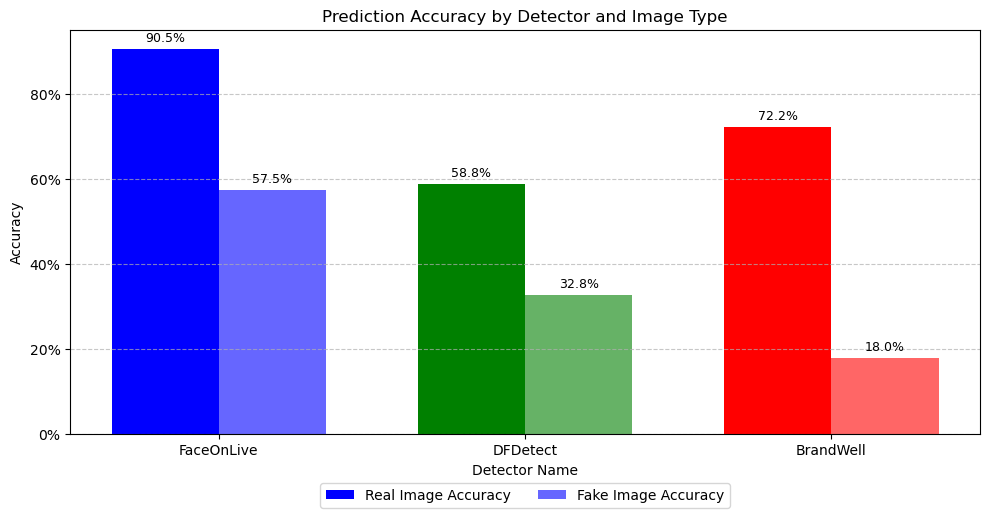

In [6]:
# Calculate accuracy
accuracy_by_type = df.groupby(['Detector_Name', 'Image_Type'])['Is_Prediction_Correct'].apply(
    lambda x: (x == 'Yes').sum() / len(x)
).reset_index(name='Accuracy')

# Pivot and sort (same as before to keep the order: FaceOnLive, DFDetect, BrandWell)
pivot_df = accuracy_by_type.pivot(index='Detector_Name', columns='Image_Type', values='Accuracy').reset_index()
overall_accuracy = df.groupby('Detector_Name')['Is_Prediction_Correct'].apply(
    lambda x: (x == 'Yes').sum() / len(x)
).sort_values(ascending=False).index.tolist()
pivot_df['Detector_Name'] = pd.Categorical(pivot_df['Detector_Name'], categories=overall_accuracy, ordered=True)
pivot_df = pivot_df.sort_values('Detector_Name')

# Matplotlib Grouped Bar Chart with Custom Colors
labels = pivot_df['Detector_Name']
real_acc = pivot_df['Real']
fake_acc = pivot_df['Fake']

x = np.arange(len(labels))
width = 0.35

# Custom color list matching the sorted order (FaceOnLive, DFDetect, BrandWell)
detector_colors = ['blue', 'green', 'red']

plt.figure(figsize=(10, 6))

# Plotting Real Accuracy bars (Full opacity)
rects1 = plt.bar(x - width/2, real_acc, width, label='Real Image Accuracy', color=detector_colors, alpha=1.0)

# Plotting Fake Accuracy bars (Slight transparency to distinguish them)
rects2 = plt.bar(x + width/2, fake_acc, width, label='Fake Image Accuracy', color=detector_colors, alpha=0.6)

# Function to attach a text label above each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.1%}',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9)

autolabel(rects1)
autolabel(rects2)

# Add labels, title, etc.
plt.ylabel('Accuracy')
plt.title('Prediction Accuracy by Detector and Image Type')
plt.xlabel('Detector Name')
plt.xticks(x, labels)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Format y-axis to show percentage
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))

plt.tight_layout(rect=[0, 0.1, 1, 1])

# Show the plot
plt.show()

In [7]:
# Calculate the accuracy grouped by Detector_Name and Compression_Quality
accuracy_by_quality = df.groupby(['Detector_Name', 'Compression_Quality'])['Is_Prediction_Correct'].apply(
    lambda x: (x == 'Yes').mean()
).reset_index(name='Accuracy')

# Ensure Compression_Quality is treated as an ordered quantitative variable
accuracy_by_quality = accuracy_by_quality.sort_values(by=['Compression_Quality', 'Detector_Name'])

# --- Custom Color Setup ---
# Define the custom domain (detector names) and range (specified colors)
color_domain = ['FaceOnLive', 'DFDetect', 'BrandWell']
color_range = ['blue', 'green', 'red']

# Create the Altair line chart with custom color scale
chart = alt.Chart(accuracy_by_quality).mark_line(point=True).encode(
    x=alt.X('Compression_Quality', title='Compression Quality (Lower is Worse Quality)', scale=alt.Scale(nice=False)),
    y=alt.Y('Accuracy', axis=alt.Axis(format='.1%'), title='Prediction Accuracy'),
    color=alt.Color('Detector_Name', scale=alt.Scale(domain=color_domain, range=color_range)),
    tooltip=[
        'Detector_Name',
        'Compression_Quality',
        alt.Tooltip('Accuracy', format='.2%')
    ]
).properties(
    title='Prediction Accuracy vs. Image Quality by Detector'
).interactive()

# Add text labels for the highest and lowest quality points
# The custom color scale is applied to the text layers as well to match the lines.
high_quality_labels = accuracy_by_quality[accuracy_by_quality['Compression_Quality'] == 30]
text_high = alt.Chart(high_quality_labels).mark_text(
    align='left',
    dx=5,
    dy=0
).encode(
    x='Compression_Quality',
    y='Accuracy',
    text=alt.Text('Accuracy', format='.1%'),
    color=alt.Color('Detector_Name', scale=alt.Scale(domain=color_domain, range=color_range))
)

low_quality_labels = accuracy_by_quality[accuracy_by_quality['Compression_Quality'] == 1]
text_low = alt.Chart(low_quality_labels).mark_text(
    align='right',
    dx=-5,
    dy=0
).encode(
    x='Compression_Quality',
    y='Accuracy',
    text=alt.Text('Accuracy', format='.1%'),
    color=alt.Color('Detector_Name', scale=alt.Scale(domain=color_domain, range=color_range))
)

final_chart = chart + text_high + text_low

# Show the chart
final_chart.show()

alt.LayerChart(...)

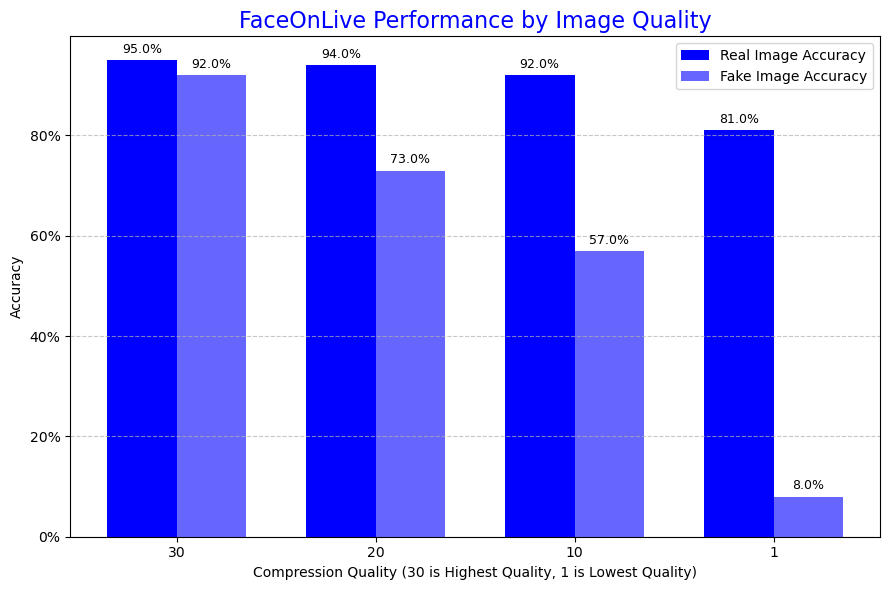

In [8]:
# Calculate accuracy grouped by Detector, Quality, and Image Type
accuracy_data = df.groupby(['Detector_Name', 'Compression_Quality', 'Image_Type'])['Is_Prediction_Correct'].apply(
    lambda x: (x == 'Yes').mean()
).reset_index(name='Accuracy')

# Pivot the table to get 'Real' and 'Fake' accuracy as separate columns
pivot_accuracy = accuracy_data.pivot_table(
    index=['Detector_Name', 'Compression_Quality'],
    columns='Image_Type',
    values='Accuracy'
).reset_index()

# Define the desired order for Compression_Quality (decreasing quality)
quality_order = [30, 20, 10, 1]
pivot_accuracy['Compression_Quality'] = pd.Categorical(
    pivot_accuracy['Compression_Quality'], categories=quality_order, ordered=True
)
pivot_accuracy = pivot_accuracy.sort_values(by=['Detector_Name', 'Compression_Quality'])

# Filter data for FaceOnLive
detector = 'FaceOnLive'
plot_data = pivot_accuracy[pivot_accuracy['Detector_Name'] == detector].copy()

# Matplotlib Grouped Bar Chart for FaceOnLive ---
main_color = 'blue'
labels = plot_data['Compression_Quality']
real_acc = plot_data['Real']
fake_acc = plot_data['Fake']

x_base = np.arange(len(quality_order))
bar_width = 0.35

plt.figure(figsize=(9, 6))

# Plot Real Accuracy (Full Opacity)
rects_real = plt.bar(
    x_base - bar_width/2,
    real_acc,
    bar_width,
    label='Real Image Accuracy',
    color=main_color,
    alpha=1.0
)

# Plot Fake Accuracy (Partial Opacity)
rects_fake = plt.bar(
    x_base + bar_width/2,
    fake_acc,
    bar_width,
    label='Fake Image Accuracy',
    color=main_color,
    alpha=0.6
)

# Function to attach a text label above each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.1%}',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9)

autolabel(rects_real)
autolabel(rects_fake)

# Set titles and labels
plt.title(f'{detector} Performance by Image Quality', color=main_color, fontsize=16)
plt.ylabel('Accuracy')
plt.xlabel('Compression Quality (30 is Highest Quality, 1 is Lowest Quality)')

# Set x-ticks to be the Compression_Quality values
plt.xticks(x_base, labels)

# Format y-axis to show percentage
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))

# Add grid and legend
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right', ncol=1)

plt.tight_layout()

# Show the plot
plt.show()     

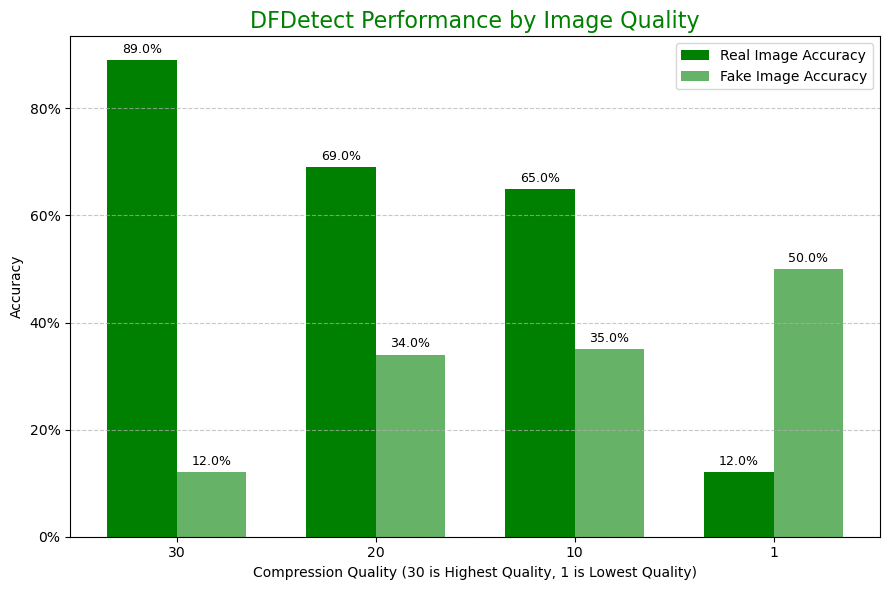

In [9]:
# Filter data for DFDetect
detector = 'DFDetect'
plot_data = pivot_accuracy[pivot_accuracy['Detector_Name'] == detector].copy()

# Matplotlib Grouped Bar Chart for DFDetect
main_color = 'green'
labels = plot_data['Compression_Quality']
real_acc = plot_data['Real']
fake_acc = plot_data['Fake']

x_base = np.arange(len(quality_order))
bar_width = 0.35

plt.figure(figsize=(9, 6))

# Plot Real Accuracy (Full Opacity)
rects_real = plt.bar(
    x_base - bar_width/2,
    real_acc,
    bar_width,
    label='Real Image Accuracy',
    color=main_color,
    alpha=1.0
)

# Plot Fake Accuracy (Partial Opacity)
rects_fake = plt.bar(
    x_base + bar_width/2,
    fake_acc,
    bar_width,
    label='Fake Image Accuracy',
    color=main_color,
    alpha=0.6
)

# Function to attach a text label above each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.1%}',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9)

autolabel(rects_real)
autolabel(rects_fake)

# Set titles and labels
plt.title(f'{detector} Performance by Image Quality', color=main_color, fontsize=16)
plt.ylabel('Accuracy')
plt.xlabel('Compression Quality (30 is Highest Quality, 1 is Lowest Quality)')

# Set x-ticks to be the Compression_Quality values
plt.xticks(x_base, labels)

# Format y-axis to show percentage
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))

# Add grid and legend
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right', ncol=1)

plt.tight_layout()

# Show the plot
plt.show()

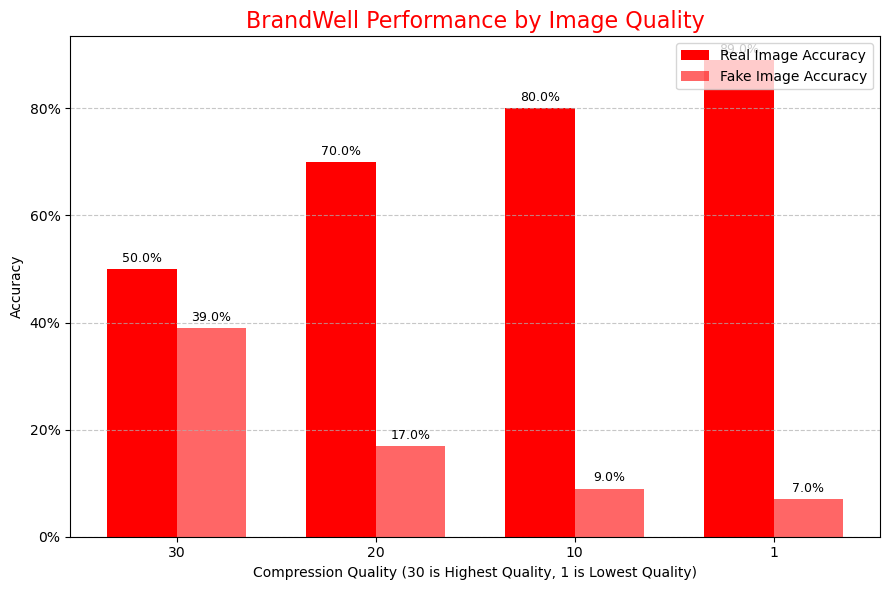

In [10]:
# Filter data for BrandWell
detector = 'BrandWell'
plot_data = pivot_accuracy[pivot_accuracy['Detector_Name'] == detector].copy()

# Matplotlib Grouped Bar Chart for BrandWell
main_color = 'red'
labels = plot_data['Compression_Quality']
real_acc = plot_data['Real']
fake_acc = plot_data['Fake']

x_base = np.arange(len(quality_order))
bar_width = 0.35

plt.figure(figsize=(9, 6))

# Plot Real Accuracy (Full Opacity)
rects_real = plt.bar(
    x_base - bar_width/2,
    real_acc,
    bar_width,
    label='Real Image Accuracy',
    color=main_color,
    alpha=1.0
)

# Plot Fake Accuracy (Partial Opacity)
rects_fake = plt.bar(
    x_base + bar_width/2,
    fake_acc,
    bar_width,
    label='Fake Image Accuracy',
    color=main_color,
    alpha=0.6
)

# Function to attach a text label above each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.1%}',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9)

autolabel(rects_real)
autolabel(rects_fake)

# Set titles and labels
plt.title(f'{detector} Performance by Image Quality', color=main_color, fontsize=16)
plt.ylabel('Accuracy')
plt.xlabel('Compression Quality (30 is Highest Quality, 1 is Lowest Quality)')

# Set x-ticks to be the Compression_Quality values
plt.xticks(x_base, labels)

# Format y-axis to show percentage
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))

# Add grid and legend
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right', ncol=1)

plt.tight_layout()

# Show the plot
plt.show()

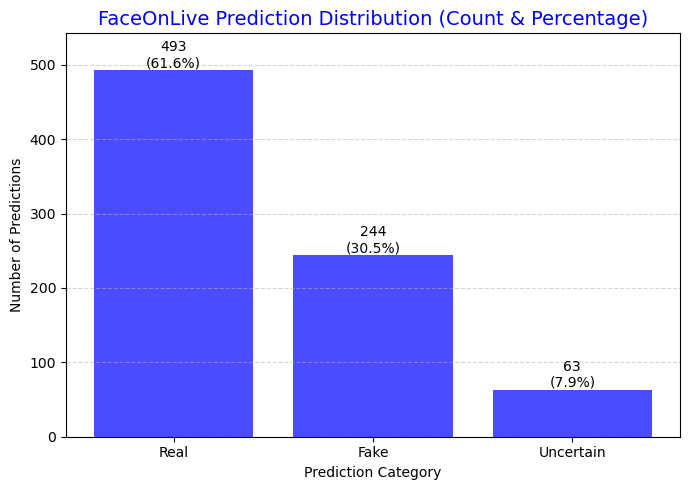

In [11]:
# Calculate counts of predictions for each detector
prediction_counts = df.groupby(['Detector_Name', 'Detector_Prediction']).size().reset_index(name='Count')

# Calculate the total number of predictions per detector
total_predictions = prediction_counts.groupby('Detector_Name')['Count'].sum().reset_index(name='Total')

# Merge counts with totals to calculate percentage
prediction_summary_df = pd.merge(prediction_counts, total_predictions, on='Detector_Name')
prediction_summary_df['Percentage'] = prediction_summary_df['Count'] / prediction_summary_df['Total']

# Define the order for predictions to ensure consistency in plotting
prediction_order = ['Real', 'Fake', 'Uncertain']
prediction_summary_df['Detector_Prediction'] = pd.Categorical(
    prediction_summary_df['Detector_Prediction'], categories=prediction_order, ordered=True
)
prediction_summary_df = prediction_summary_df.sort_values(by=['Detector_Name', 'Detector_Prediction'])

# Filter and Plot for FaceOnLive
detector = 'FaceOnLive'
plot_data = prediction_summary_df[prediction_summary_df['Detector_Name'] == detector].copy()
color = 'blue'

plt.figure(figsize=(7, 5))
bars = plt.bar(plot_data['Detector_Prediction'], plot_data['Count'], color=color, alpha=0.7)

# Add count and percentage labels
for bar, percentage in zip(bars, plot_data['Percentage']):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0,
        yval,
        f'{yval}\n({percentage:.1%})',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Set titles and labels
plt.title(f'{detector} Prediction Distribution (Count & Percentage)', color=color, fontsize=14)
plt.ylabel('Number of Predictions')
plt.xlabel('Prediction Category')

# Set y-axis to start from 0 and end a little above the highest bar
plt.ylim(0, plot_data['Count'].max() * 1.1)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()

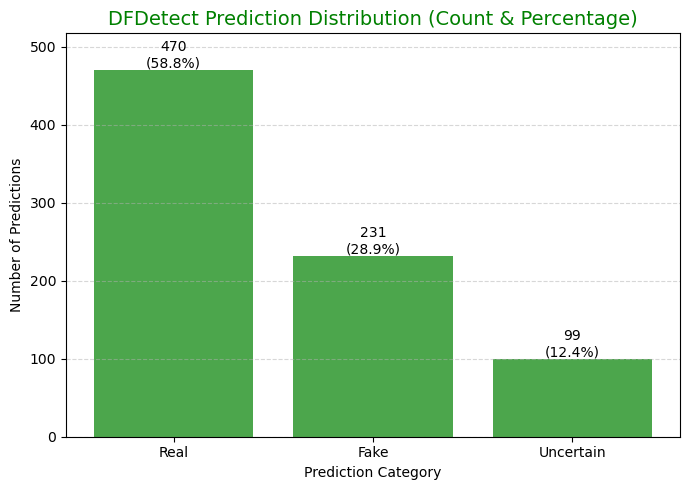

In [12]:
# Calculate counts of predictions for each detector
prediction_counts = df.groupby(['Detector_Name', 'Detector_Prediction']).size().reset_index(name='Count')

# Calculate the total number of predictions per detector
total_predictions = prediction_counts.groupby('Detector_Name')['Count'].sum().reset_index(name='Total')

# Merge counts with totals to calculate percentage
prediction_summary_df = pd.merge(prediction_counts, total_predictions, on='Detector_Name')
prediction_summary_df['Percentage'] = prediction_summary_df['Count'] / prediction_summary_df['Total']

# Define the order for predictions to ensure consistency in plotting
prediction_order = ['Real', 'Fake', 'Uncertain']
prediction_summary_df['Detector_Prediction'] = pd.Categorical(
    prediction_summary_df['Detector_Prediction'], categories=prediction_order, ordered=True
)
prediction_summary_df = prediction_summary_df.sort_values(by=['Detector_Name', 'Detector_Prediction'])

# Filter and Plot for DFDetect
detector = 'DFDetect'
plot_data = prediction_summary_df[prediction_summary_df['Detector_Name'] == detector].copy()
color = 'green'

plt.figure(figsize=(7, 5))
bars = plt.bar(plot_data['Detector_Prediction'], plot_data['Count'], color=color, alpha=0.7)

# Add count and percentage labels
for bar, percentage in zip(bars, plot_data['Percentage']):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0,
        yval,
        f'{yval}\n({percentage:.1%})',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Set titles and labels
plt.title(f'{detector} Prediction Distribution (Count & Percentage)', color=color, fontsize=14)
plt.ylabel('Number of Predictions')
plt.xlabel('Prediction Category')

# Set y-axis to start from 0 and end a little above the highest bar
plt.ylim(0, plot_data['Count'].max() * 1.1)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()

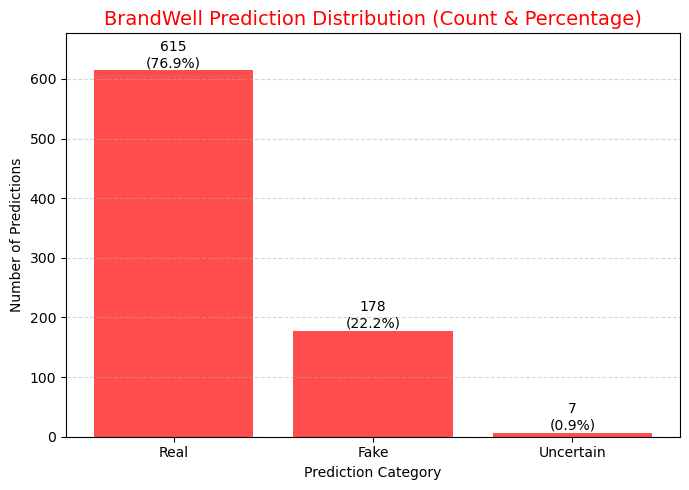

In [13]:
# Calculate counts of predictions for each detector
prediction_counts = df.groupby(['Detector_Name', 'Detector_Prediction']).size().reset_index(name='Count')

# Calculate the total number of predictions per detector
total_predictions = prediction_counts.groupby('Detector_Name')['Count'].sum().reset_index(name='Total')

# Merge counts with totals to calculate percentage
prediction_summary_df = pd.merge(prediction_counts, total_predictions, on='Detector_Name')
prediction_summary_df['Percentage'] = prediction_summary_df['Count'] / prediction_summary_df['Total']

# Define the order for predictions to ensure consistency in plotting
prediction_order = ['Real', 'Fake', 'Uncertain']
prediction_summary_df['Detector_Prediction'] = pd.Categorical(
    prediction_summary_df['Detector_Prediction'], categories=prediction_order, ordered=True
)
prediction_summary_df = prediction_summary_df.sort_values(by=['Detector_Name', 'Detector_Prediction'])

# Filter and Plot for BrandWell
detector = 'BrandWell'
plot_data = prediction_summary_df[prediction_summary_df['Detector_Name'] == detector].copy()
color = 'red'

plt.figure(figsize=(7, 5))
bars = plt.bar(plot_data['Detector_Prediction'], plot_data['Count'], color=color, alpha=0.7)

# Add count and percentage labels
for bar, percentage in zip(bars, plot_data['Percentage']):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0,
        yval,
        f'{yval}\n({percentage:.1%})',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Set titles and labels
plt.title(f'{detector} Prediction Distribution (Count & Percentage)', color=color, fontsize=14)
plt.ylabel('Number of Predictions')
plt.xlabel('Prediction Category')

# Set y-axis to start from 0 and end a little above the highest bar
plt.ylim(0, plot_data['Count'].max() * 1.1)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()

In [14]:
# Creating a Classification Report for Each Open Source Tool
from sklearn.metrics import classification_report

# Check unique values for the key columns
print("Unique Detector_Name values:", df['Detector_Name'].unique())
print("Unique Image_Type values:", df['Image_Type'].unique())
print("Unique Detector_Prediction values:", df['Detector_Prediction'].unique())

# Filter out 'Uncertain' predictions as they are not a definitive classification
df_classified = df[df['Detector_Prediction'] != 'Uncertain'].copy()

# Ensure the true labels and predicted labels only contain 'Real' and 'Fake'
if 'Uncertain' in df_classified['Image_Type'].unique():
    print("Warning: 'Uncertain' found in Image_Type after filtering.")

# Get the list of detectors
detectors = df_classified['Detector_Name'].unique()

# Store reports
reports = {}

# Generate a classification report for each detector
for detector in detectors:
    # Filter data for the current detector
    df_detector = df_classified[df_classified['Detector_Name'] == detector]

    # True labels (y_true)
    y_true = df_detector['Image_Type']
    # Predicted labels (y_pred)
    y_pred = df_detector['Detector_Prediction']

    # Generate the report
    report = classification_report(y_true, y_pred, zero_division=0)
    reports[detector] = report

# Print all reports
output = "Classification Reports for Each Detector (Excluding 'Uncertain' Predictions):\n\n"
for detector, report in reports.items():
    output += f"--- {detector} ---\n"
    output += report + "\n"

print(output)

Unique Detector_Name values: ['FaceOnLive' 'BrandWell' 'DFDetect']
Unique Image_Type values: ['Real' 'Fake']
Unique Detector_Prediction values: ['Real' 'Uncertain' 'Fake']
Classification Reports for Each Detector (Excluding 'Uncertain' Predictions):

--- FaceOnLive ---
              precision    recall  f1-score   support

        Fake       0.94      0.64      0.76       361
        Real       0.73      0.96      0.83       376

    accuracy                           0.80       737
   macro avg       0.84      0.80      0.80       737
weighted avg       0.84      0.80      0.80       737

--- BrandWell ---
              precision    recall  f1-score   support

        Fake       0.40      0.18      0.25       398
        Real       0.47      0.73      0.57       395

    accuracy                           0.46       793
   macro avg       0.44      0.46      0.41       793
weighted avg       0.44      0.46      0.41       793

--- DFDetect ---
              precision    recall  f1-sco